In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from pyparsing import results
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score
df=pd.read_csv("IPLPlayerStat.csv")
df.head()
sb.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7,5)
NAVY="#004BA0"
GOLD="#D1AB3E"

In [4]:
if "Unnamed: 0" in df.columns:
    df.drop(columns="Unnamed: 0",inplace=True)
df.head()

,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [5]:
df["balls_faced"].describe()

count     605.000000
mean      373.477686
std       764.432561
min         1.000000
25%        18.000000
50%        73.000000
75%       285.000000
max      5266.000000
Name: balls_faced, dtype: float64

In [6]:
print(df.isnull().sum())

player                 0
runs                   0
boundaries             0
balls_faced            0
wickets                0
balls_bowled           0
runs_conceded          0
matches                0
batting_avg            0
batting_strike_rate    0
boundaries_percent     0
bowling_economy        0
bowling_avg            0
bowling_strike_rate    0
catches                0
stumpings              0
dtype: int64


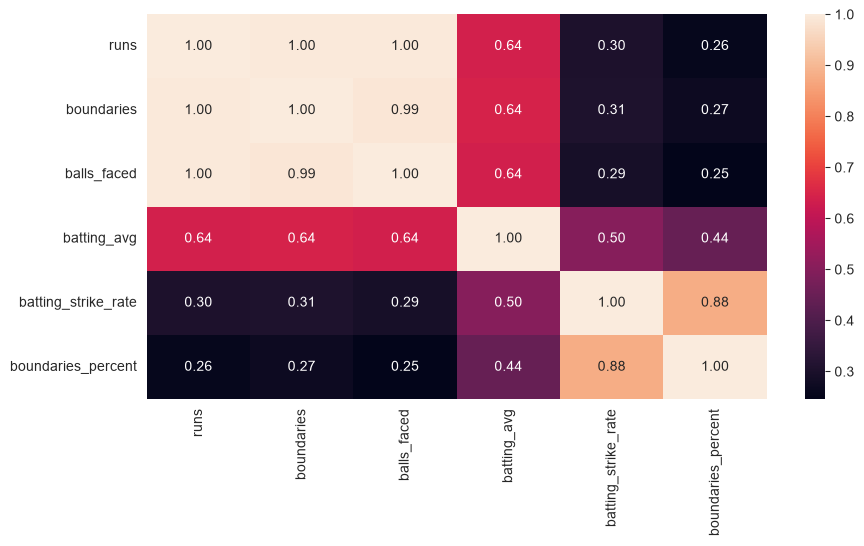

In [9]:
cols=["runs","boundaries","balls_faced","batting_avg","batting_strike_rate","boundaries_percent"]
plt.figure(figsize=(10,5))
sb.heatmap(df[cols].corr(),annot=True,fmt=".2f")
plt.show()

In [10]:
x=df[["balls_faced"]]
y=df["runs"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
print("intercept",model.intercept_)
print("coefficients",model.coef_[0])
print(f"every extra ball faced add {model.coef_[0]:.2f} runs on average")

intercept -15.330465838412863
coefficients 1.284369828647767
every extra ball faced add 1.28 runs on average


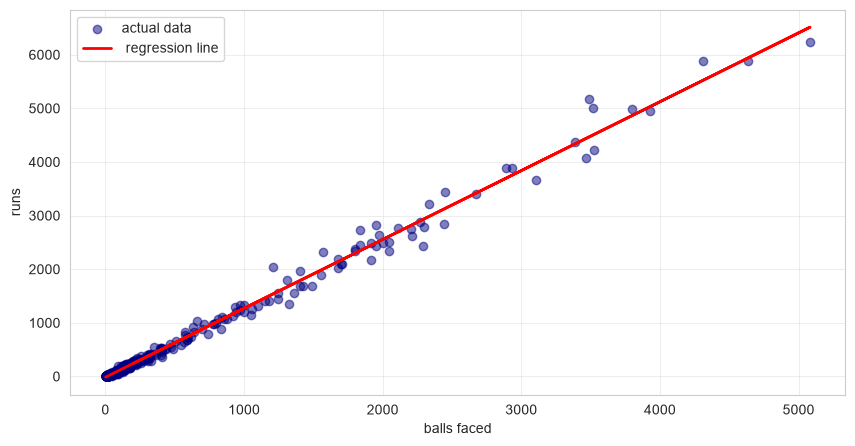

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(x_train,y_train,color="navy",alpha=0.5,label="actual data")
plt.plot(x_train,model.predict(x_train),color="red",label=" regression line",linewidth=2)
#plt.plot(x_train,y_train,color="blue",label=" regression line",linewidth=2)
plt.xlabel("balls faced")
plt.ylabel("runs")
plt.legend()
plt.show()

In [12]:
y_pred=model.predict(x_test)
comparison=pd.DataFrame({
    "balls_faced":x_test["balls_faced"].values,
    "actual_runs":y_test.values,
    "predicted_runs":np.round(y_pred,1)
})
comparison.head(10)

,balls_faced,actual_runs,predicted_runs
0,434,522,542.1
1,27,40,19.3
2,57,76,57.9
3,31,21,24.5
4,552,663,693.6
5,865,985,1095.6
6,26,34,18.1
7,9,12,-3.8
8,18,20,7.8
9,703,920,887.6


In [13]:
new_player=pd.DataFrame({"balls_faced":[100,200,300]})
new_pred=model.predict(new_player)
for balls,runs in zip(new_player["balls_faced"],new_pred):
    print(f"balls faced: {balls} -> runs: {runs}")

balls faced: 100 -> runs: 113.10651702636383
balls faced: 200 -> runs: 241.54349989114053
balls faced: 300 -> runs: 369.9804827559172


In [17]:
features=["balls_faced","boundaries","balls_bowled","stumpings","batting_strike_rate"]
x_multi=df[features]
y_multi=df["runs"]
x_train_m,x_test_m,y_train_m,y_test_m=train_test_split(x_multi,y_multi,test_size=0.2,random_state=42)
multi_model=LinearRegression()
multi_model.fit(x_train_m,y_train_m)
print("intercept: ",multi_model.intercept_)
print("coefficients: ",multi_model.coef_)

intercept:  -18.074738487272327
coefficients:  [0.68047683 3.53264418 0.00447692 2.26140863 0.13585206]


In [18]:
y_pred_multi=multi_model.predict(x_test_m)
pd.DataFrame({
    "actual":y_test_m.values[:10],"predicted":y_pred_multi[:10]
})

,actual,predicted
0,522,513.341694
1,40,41.647345
2,76,75.016084
3,21,19.287950
4,663,649.411911
5,985,989.722511
6,34,36.443054
7,12,9.807275
8,20,16.978332
9,920,873.412894


In [20]:
def adjusted_r2(r2,n,p):
    return 1-(1-r2)*(n-1)/(n-p-1)
def evaluate(name,y_true,y_pred,n_feature):
    mae=mean_absolute_error(y_true,y_pred)
    r2=r2_score(y_true,y_pred)
    mse=mean_squared_error(y_true,y_pred)
    rmse=root_mean_squared_error(y_true,y_pred)
    adj_r2=adjusted_r2(r2,len(y_true),n_feature)
    print(f"--{name}--")
    print(f"MAE:{mae:.2f}")
    print(f"R2:{r2:.4f}")
    print(f"MSE:{mse:.2f}")
    print(f"RMSE:{rmse:.2f}")
    print(f"adj R2:{adj_r2:.4f}")
    return {"model":name,"MAE":mae,"R2":r2,"MSE":mse,"RMSE":rmse,"adj R2":adj_r2}
results=[]
results.append(evaluate("simple linear regression",y_test,y_pred,n_feature=1))
results.append(evaluate("multi linear regression",y_test_m,y_pred_multi,n_feature=14))

--simple linear regression--
MAE:33.81
R2:0.9968
MSE:3246.97
RMSE:56.98
adj R2:0.9967
--multi linear regression--
MAE:19.18
R2:0.9984
MSE:1619.34
RMSE:40.24
adj R2:0.9982
